In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [4]:
# load dataset
data = pd.read_csv("C:\\Users\\prana\\OneDrive\\Desktop\\tekworks\\day 22\\Tax.csv")
data

,Unnamed: 0,HHI,HHDL,Married,CollegGrads,AHHAge,Cars,Filed in 2017,Filed in 2016,Filed in 2015,PoliticalParty
0,1,49685,227187,0,0,105,0,1,1,1,Democrat
1,2,64756,-507342,2,3,68,3,1,0,0,Independent
2,3,115435,521290,1,3,81,2,0,1,0,Republican
3,4,99454,251829,2,1,52,4,1,0,0,Republican
4,5,157274,-472337,0,1,28,1,1,0,1,Independent
...,...,...,...,...,...,...,...,...,...,...,...
999,1000,37626,20830,0,1,38,4,0,1,0,Democrat
1000,1001,79765,63483,2,1,71,5,0,1,0,Republican
1001,1002,111219,-573449,0,4,35,2,0,0,0,Republican
1002,1003,105591,-611207,0,1,59,1,1,1,0,Republican


In [5]:
# Check for missing values
data.isnull().sum()

Unnamed: 0        0
HHI               0
HHDL              0
Married           0
CollegGrads       0
AHHAge            0
Cars              0
Filed in 2017     0
Filed in 2016     0
Filed in 2015     0
PoliticalParty    0
dtype: int64

In [6]:
# Dataset information
print("\nDataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)




Dataset Shape:
(1004, 11)

Column Names:
Index(['Unnamed: 0', 'HHI', 'HHDL', 'Married', 'CollegGrads', 'AHHAge', 'Cars',
       'Filed in 2017', 'Filed in 2016', 'Filed in 2015', 'PoliticalParty'],
      dtype='object')


In [7]:
# Check Missing Values
print("\nMissing Values:\n")
print(data.isnull().sum())


Missing Values:

Unnamed: 0        0
HHI               0
HHDL              0
Married           0
CollegGrads       0
AHHAge            0
Cars              0
Filed in 2017     0
Filed in 2016     0
Filed in 2015     0
PoliticalParty    0
dtype: int64


In [8]:
# Drop Unnecessary Column
# Remove index-like column
data.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
# Encode Target Column
# Convert PoliticalParty into numerical values
le = LabelEncoder()
data["PoliticalParty"] = le.fit_transform(data["PoliticalParty"])
print("\nEncoded Classes:")
print(le.classes_)


Encoded Classes:
['Democrat' 'Independent' 'Republican']


In [10]:
# Define Features and Target
X = data.drop("PoliticalParty", axis=1)
X
y = data["PoliticalParty"]
y


0       0
1       1
2       2
3       2
4       1
       ..
999     0
1000    2
1001    2
1002    2
1003    2
Name: PoliticalParty, Length: 1004, dtype: int64

In [11]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)



Training Data Shape:
(803, 9)

Testing Data Shape:
(201, 9)


In [12]:
# Build Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# Train model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# Predictions
y_pred = rf.predict(X_test)
y_pred


array([0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0,
       0, 0, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 2, 1,
       2, 2, 1, 2, 2, 1, 1, 0, 1, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 0, 2, 0, 1,
       0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 0,
       2, 2, 2, 2, 0, 2, 0, 1, 1, 0, 2, 1, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1,
       0, 1, 0, 1, 2, 2, 0, 2, 0, 1, 0, 1, 1, 2, 2, 0, 1, 2, 2, 1, 2, 2,
       0, 0, 0, 1, 1, 2, 1, 1, 2, 1, 2, 0, 2, 2, 0, 1, 1, 0, 0, 2, 2, 1,
       0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 0, 2, 1, 2, 0, 0, 1, 1, 2, 0, 1,
       0, 0, 2])

In [15]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:")
print(accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy Score:
0.3681592039800995

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.37      0.36        73
           1       0.39      0.38      0.39        68
           2       0.35      0.35      0.35        60

    accuracy                           0.37       201
   macro avg       0.37      0.37      0.37       201
weighted avg       0.37      0.37      0.37       201



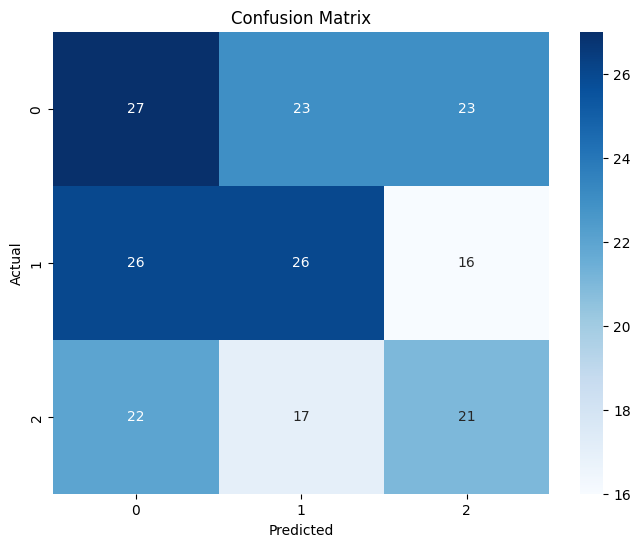

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
# Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(feature_importance)



Feature Importance:

         Feature  Importance
1           HHDL    0.227990
0            HHI    0.218115
4         AHHAge    0.196479
5           Cars    0.095672
3    CollegGrads    0.095186
2        Married    0.064023
7  Filed in 2016    0.037796
6  Filed in 2017    0.033777
8  Filed in 2015    0.030962


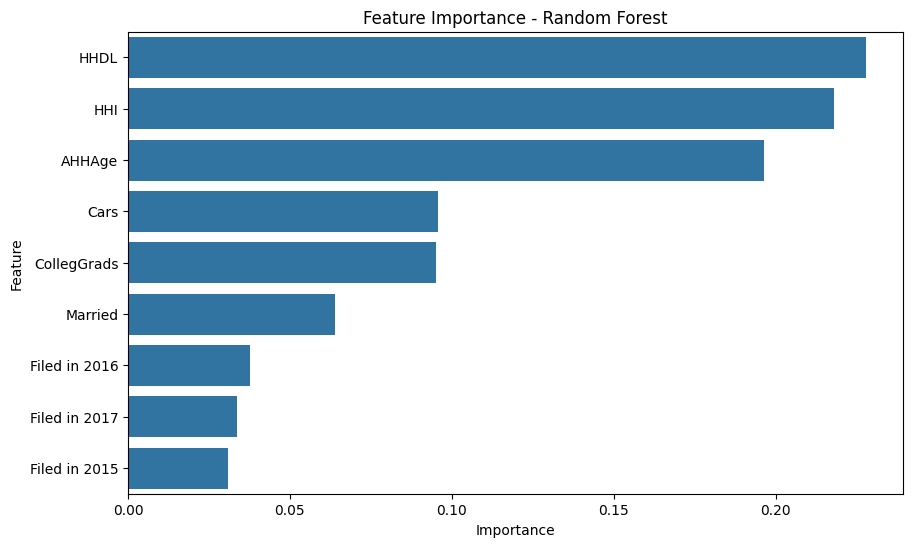

In [18]:
# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("Feature Importance - Random Forest")
plt.show()



In [19]:
# Sample Prediction
sample_prediction = rf.predict([X_test.iloc[0]])

print("\nSample Prediction:")
print(sample_prediction)

print("\nActual Value:")
print(y_test.iloc[0])


Sample Prediction:
[0]

Actual Value:
1


c:\Users\prana\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
